In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sbn
import numpy as np
import statsmodels.api as sm

In [2]:
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'primary_disease', 'Subtype']].dropna()

expr_mirna = pd.read_csv('~/local/data/ccle/CCLE_miRNA_20180525.gct', sep='\t', skiprows=2)
expr_mirna = expr_mirna.drop(columns=['Name']).set_index('Description').T.reset_index().rename(columns={'index': 'CCLE_Name'})
expr_mirna = expr_mirna.merge(cell_info, left_on='CCLE_Name', right_on='CCLE_Name', how='left')

expr_mrna = pd.read_csv('~/local/data/ccle/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')
expr_mrna = expr_mrna.merge(cell_info, left_on='ModelID', right_on='DepMap_ID', how='left')

In [16]:
expr = expr_mrna.merge(expr_mirna, left_on=['DepMap_ID', 'primary_disease', 'Subtype'], right_on=['DepMap_ID', 'primary_disease', 'Subtype'], how='inner')

In [17]:
genes = [] 
genes += [x for x in expr.columns if 'miR-181a' in x]
genes += [x for x in expr.columns if 'miR-101' in x]
genes += [x for x in expr.columns if 'miR-125b' in x]
genes += [x for x in expr.columns if 'FOXO3 (2309)' in x]
genes += [x for x in expr.columns if 'ETS1' in x]

target = [x for x in expr.columns if 'DUSP6' in x]

In [18]:
# z score (over all cell lines )
expr.loc[:, genes + target] = expr.loc[:, genes + target].apply(lambda x: (x - x.mean()) / x.std())

# subset to breast 
expr = expr[lambda x: x.primary_disease == 'Breast Cancer']

In [31]:
expr[genes + target].corr(method='pearson')[['DUSP6 (1848)']].loc[genes].sort_values(by='DUSP6 (1848)', ascending=False)

,DUSP6 (1848)
hsa-miR-181a,0.203440
hsa-miR-125b,0.104499
ETS1 (2113),0.062144
FOXO3 (2309),-0.072704
hsa-miR-101,-0.119180


In [32]:
expr[genes + target].corr(method='spearman')[['DUSP6 (1848)']].loc[genes].sort_values(by='DUSP6 (1848)', ascending=False)

,DUSP6 (1848)
hsa-miR-125b,0.157334
hsa-miR-181a,0.076246
ETS1 (2113),0.046516
FOXO3 (2309),-0.081086
hsa-miR-101,-0.117242


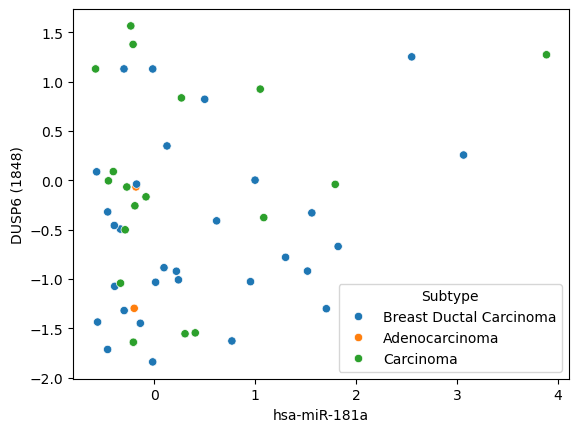

In [21]:
plt.figure() 
sbn.scatterplot(x='hsa-miR-181a', y='DUSP6 (1848)', data=expr, hue='Subtype')
plt.show() 

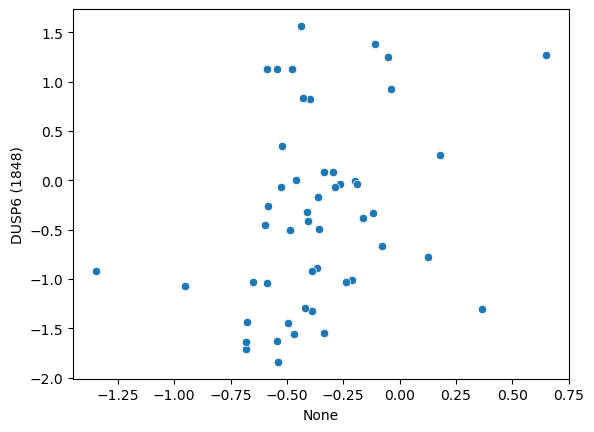

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           DUSP6 (1848)   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.090
Date:                Fri, 23 Jan 2026   Prob (F-statistic):              0.379
Time:                        16:40:05   Log-Likelihood:                -66.478
No. Observations:                  51   AIC:                             145.0
Df Residuals:                      45   BIC:                             156.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2553      0.345     -0.739      0.464      -0.951       0.440
hsa-miR-181a     0.3104      0.160      1.939      0.059      -0.012       0.633
hsa-miR-101     -0.1506      0.106     -1.424      0.161      -0.364       0.062
hsa-miR-125b     0.1375      0.571      0.241      0.811      -1.013       1.288
FOXO3 (2309)    -0.0646      0.180     -0.359      0.721      -0.427       0.297
ETS1 (2113)      0.0894      0.144      0.622      0.537      -0.200       0.379
==============================================================================
Omnibus:                        2.473   Durbin-Watson:                   2.320
Prob(Omnibus):                  0.290   Jarque-Bera (JB):                2.170
Skew:                           0.397   Prob(JB):                        0.338
Kurtosis:                       2.376   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
# multivariate regression to predict DUSP6 expression from mRNA expr 

X = expr[genes]
y = expr[target[0]]

reg = sm.OLS(y, sm.add_constant(X)).fit()

yhat = reg.predict(sm.add_constant(X))

plt.figure() 
sbn.scatterplot(x=yhat, y=y, data=expr)
plt.show() 

reg.summary()



In [ ]:
# random forest regression on X,y and get feature importances 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

X = expr[genes].values
y = expr[target].values.ravel()

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'gene': genes,
    'importance': importances
}).sort_values('importance', ascending=False)

# Cross-validated R^2 score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Plot feature importances
plt.figure(figsize=(8, 5))
sbn.barplot(data=importance_df, x='importance', y='gene', palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Gene')
plt.title('Random Forest Feature Importances for DUSP6 Prediction')
plt.tight_layout()
plt.show()

importance_df


In [23]:
# Compute Mutual Information between each gene in `genes` and DUSP6
from sklearn.feature_selection import mutual_info_regression

N = 2500
BS = 0.75
Ks = [3, 4, 5, 6, 7, 8]
jitter = 1e-6

# Get MI for each predictor with DUSP6
X = expr[genes].values
y = expr[target].values

# mutual_info_regression handles continuous variables

mi_scores = []
for i in range(N): 
    K = np.random.choice(Ks)
    print(f'progress: {i}/{N}', end='\r')
    ixs = np.random.choice(np.arange(len(X)), size=len(X), replace=True)

    xx = X[ixs] + np.random.randn(*X[ixs].shape) * jitter 
    yy = y[ixs] + np.random.randn(*y[ixs].shape) * jitter 

    mi_scores.append ( mutual_info_regression(xx, yy.ravel(), 
                                    discrete_features=[False for _ in genes],
                                    n_neighbors=K) ) 

mi_scores = np.stack(mi_scores, axis=0)

# Create a DataFrame with results
mi_df = pd.DataFrame({
    'gene': genes,
    'MI_mean': mi_scores.mean(axis=0),
    'MI_std': mi_scores.std(axis=0), 
    'nnz_mi_p': (mi_scores <= 0).sum(axis=0) / N
}).sort_values('MI_mean', ascending=False)

mi_df

,gene,MI_mean,MI_std,nnz_mi_p
3,FOXO3 (2309),0.231017,0.190800,0.0504
0,hsa-miR-181a,0.194818,0.171292,0.0512
4,ETS1 (2113),0.175093,0.169486,0.0844
1,hsa-miR-101,0.174054,0.164107,0.0860
2,hsa-miR-125b,0.121974,0.168327,0.3240


In [14]:
# X: (n, 6) regulators
# y: (n,) target gene
Xs = expr[genes].values
ys = expr[target].values

def partial_corr(x, y, Z):
    """
    Partial correlation corr(x, y | Z) via residualization (with intercept).
    x, y: (n,) 1D
    Z:   (n,k)
    """
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    Z = np.asarray(Z)

    n = len(x)
    assert len(y) == n and Z.shape[0] == n

    # Add intercept to Z
    Z1 = np.column_stack([np.ones(n), Z])  # (n, k+1)

    # Residualize x and y on Z
    bx = np.linalg.lstsq(Z1, x, rcond=None)[0]
    by = np.linalg.lstsq(Z1, y, rcond=None)[0]
    rx = x - Z1 @ bx
    ry = y - Z1 @ by

    rx = rx.ravel()
    ry = ry.ravel()

    # Guard against zero-variance residuals
    sx = rx.std(ddof=1)
    sy = ry.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan

    return np.corrcoef(rx, ry)[0, 1]

def gaussian_cmi_from_partial_corr(rho):
    rho = np.clip(rho, -0.999999, 0.999999)
    return -0.5 * np.log(1 - rho**2)

results = []
for j, gene in enumerate(genes):
    xj = Xs[:, j].ravel()                 # (n,)
    Z  = np.delete(Xs, j, axis=1)         # (n,5)

    rho = partial_corr(xj, ys, Z)
    cmi = gaussian_cmi_from_partial_corr(rho) if np.isfinite(rho) else np.nan

    results.append({"gene": gene, "partial_corr": rho, "CMI_gaussian": cmi})

mi_df = pd.DataFrame(results).sort_values("CMI_gaussian", ascending=False)
mi_df

,gene,partial_corr,CMI_gaussian
0,hsa-miR-181a,0.277718,0.040132
1,hsa-miR-101,-0.207604,0.022028
4,ETS1 (2113),0.092389,0.004286
3,FOXO3 (2309),-0.053499,0.001433
2,hsa-miR-125b,0.035852,0.000643


In [15]:
import numpy as np
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler
from functools import reduce
from operator import add

def make_terms(k, n_splines=5):
    return reduce(add, (s(i, n_splines=n_splines) for i in range(k)))

def spline_partial_corr(x, y, Z, n_splines=5, lam=1.0):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    Z = np.asarray(Z)
    n, k = Z.shape

    terms = make_terms(k, n_splines=n_splines)

    gam_x = LinearGAM(terms, lam=lam).fit(Z, x)
    gam_y = LinearGAM(terms, lam=lam).fit(Z, y)

    rx = x - gam_x.predict(Z)
    ry = y - gam_y.predict(Z)

    sx, sy = rx.std(ddof=1), ry.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan

    return np.corrcoef(rx, ry)[0, 1]


rows = []
for j, g in enumerate(genes):
    xj = Xs[:, j]
    Z  = np.delete(Xs, j, axis=1)
    rho = spline_partial_corr(xj, ys, Z, n_splines=5, lam=1.0)
    rows.append({"gene": g, "partial_corr_spline": rho, "abs": np.abs(rho)})

df = pd.DataFrame(rows).sort_values("abs", ascending=False)
df


,gene,partial_corr_spline,abs
0,hsa-miR-181a,0.281575,0.281575
1,hsa-miR-101,-0.187096,0.187096
4,ETS1 (2113),0.087474,0.087474
3,FOXO3 (2309),-0.065437,0.065437
2,hsa-miR-125b,0.025262,0.025262
